# Synthetic Parameter Recovery via pyVBMC — condition-stratified linking function

Validates the full inference pipeline end-to-end: generate synthetic data from **known** GP
parameters under the condition-stratified design, then run the same pyVBMC machinery used on
the real data (`model-study9-vbmc-condition-stratified-linking.ipynb`) and check whether it
recovers the true `(length_scale, mu_0)`.

This is the condition-stratified counterpart to `model-synthetic-recovery-vbmc.ipynb` (which used
a single pooled training set / non-stratified linking function). It tells us whether stratifying
by condition — letting the per-feature Beta shapes be condition-invariant while coherence is
condition-specific — actually buys back identifiability, or whether the boundary-hugging posterior
seen on real data persists even when we know the ground truth.

**Generative model** (matches the condition-stratified inference exactly):
1. Each condition `c` (diet / personality / physical / heterogeneous) trains generic utterances
   about its own region only (`u_train_cond[c]` is fixed by design — all zeros/generic — not a
   latent draw).
2. For each condition, sample an **independent** latent coherence draw
   `y_c = (y_test_c, y_train_c) ~ MVN(mu_0, K_θ)` over `[x_test, x_train_cond[c]]`, at the true
   `(length_scale, mu_0, output_scale)`. Each condition gets its own coherence field, as in the
   inference model — only the GP hyperparameters are shared across conditions.
3. For each test feature, `pz1_test_c[j] = sigmoid(y_test_c[j])`; each participant in condition
   `c` draws `z ~ Bernoulli(pz1_test_c[j])` then a rating from `Beta(kl)` if z=1 else `Beta(nkl)`,
   rounded to the 0-100 slider grid. The Beta shapes (`kl`/`nkl`) are shared across conditions —
   only the participant counts and `pz1` differ by condition.

Then recover `(length_scale, mu_0)` with pyVBMC, fitting the SHARED Beta-mixture shapes once per
eval across all conditions' participants (weighted by each condition's own coherence draws), and
scoring each condition's draws under those shared shapes — identical machinery to the real-data
condition-stratified notebook.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
from pyvbmc import VBMC

from model_jax import (
    rbf_kernel,
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

backend: cpu


## Ground-truth parameters and feature geometry

True params are interior to the VBMC bounds (not on a boundary), so recovery is a fair test.
Feature embeddings and the per-condition trained regions are the real ones, so the spatial
geometry — and hence how identifiable the length scale is — matches the real experiment.

In [2]:
# Ground-truth parameters to recover
TRUE_PARAMS = {
    'length_scale': 2.1,
    'mu_0':         0.5,
    'output_scale': 1.5,
    'beta':         3.0,
}

with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

CONDITIONS  = ['diet', 'personality', 'physical', 'heterogeneous']
CAT_OF_COND = {'diet':'diet_preferences', 'personality':'personality_behaviors', 'physical':'physical'}
CAT_SHORT   = {'diet_preferences':'diet', 'personality_behaviors':'personality', 'physical':'physical'}

x_train_cond, u_train_cond = {}, {}
for c in CONDITIONS:
    sub = train_df[train_df.in_heterogenous] if c == 'heterogeneous' else train_df[train_df.category == CAT_OF_COND[c]]
    x_train_cond[c] = jnp.array(sub[['x_2d', 'y_2d']].values)
    u_train_cond[c] = jnp.zeros(len(sub), dtype=jnp.int32)   # all generic, localized to the region -- fixed by design
    print(f"  {c:<14}: {len(sub)} trained features")

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':'can eat spicy food','diet_breakfast_late_1':'eat breakfast very late',
    'diet_five_meals_day_1':'eat five meals a day','diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':'put pepper on all their foods','pers_cry_easily_1':'cry easily',
    'pers_collect_rocks_1':'like to collect rocks','pers_like_to_dance_1':'like to dance',
    'pers_like_highfive_1':'like to give high-fives','pers_read_books_1':'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue','phys_can_snap_toes_1':'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears','phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':'snore when they sleep'}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
x_test     = jnp.array([feat_idx.loc[n, ['x_2d','y_2d']].values for n in test_feature_names])  # (J,2)
test_trait = [CAT_SHORT[feat_idx.loc[n, 'category']] for n in test_feature_names]
J = x_test.shape[0]

print(f"True params: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']}")

  diet          : 15 trained features
  personality   : 15 trained features
  physical      : 15 trained features
  heterogeneous : 15 trained features
True params: ls=2.1, mu_0=0.5


## 1. Sample per-condition latent coherences

`u_train_cond` is fixed by design (every condition hears only generic statements about its own
region) — it's not a generative latent here, unlike the pooled non-stratified model where
utterances were drawn from the speaker model. The only thing we sample per condition is the GP
coherence field over `[x_test, x_train_cond[c]]`.

In [3]:
rng = np.random.default_rng(37)

# test first then train (matches make_log_density_fn_joint convention) -- one independent
# GP draw PER CONDITION, since each condition has its own trained region / coherence field.
y_test_true_cond, pz1_test_true_cond = {}, {}
for c in CONDITIONS:
    n_train_c = x_train_cond[c].shape[0]
    X_all = jnp.vstack([x_test, x_train_cond[c]])
    mu    = jnp.full(J + n_train_c, TRUE_PARAMS['mu_0'])
    K     = rbf_kernel(X_all, TRUE_PARAMS['length_scale'], TRUE_PARAMS['output_scale'])

    y_all = rng.multivariate_normal(np.array(mu), np.array(K))
    y_test_true_cond[c]   = y_all[:J]
    pz1_test_true_cond[c] = 1 / (1 + np.exp(-y_test_true_cond[c]))

    print(f"  {c:<14}: y_test range [{y_test_true_cond[c].min():.2f}, {y_test_true_cond[c].max():.2f}]  "
          f"pz1 range [{pz1_test_true_cond[c].min():.2f}, {pz1_test_true_cond[c].max():.2f}]  "
          f"(realized mean y_test={y_test_true_cond[c].mean():.3f}; true mu_0="
          f"{TRUE_PARAMS['mu_0']} -- sampling scatter means recovered mu_0 may shift slightly)")

  diet          : y_test range [-1.16, -0.63]  pz1 range [0.24, 0.35]  (realized mean y_test=-0.865; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  personality   : y_test range [0.20, 0.31]  pz1 range [0.55, 0.58]  (realized mean y_test=0.264; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  physical      : y_test range [0.24, 0.98]  pz1 range [0.56, 0.73]  (realized mean y_test=0.608; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  heterogeneous : y_test range [-0.39, -0.29]  pz1 range [0.40, 0.43]  (realized mean y_test=-0.339; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)


## 2. Sample ratings per condition (discretized to the 0-100 slider grid)

Rounding to the slider grid matches the real data and lets the interval-likelihood fit compact
to unique values (fast). True linking-function shapes: kind-linked = high prevalence, not = low.
The Beta shapes are shared across conditions; only each condition's own `pz1_test_true_cond[c]`
(and its participant count) differ.

  diet          : 100 participants -> responses (100, 15)
  personality   : 100 participants -> responses (100, 15)
  physical      : 100 participants -> responses (100, 15)
  heterogeneous : 100 participants -> responses (100, 15)
stacked responses_all: (400, 15)


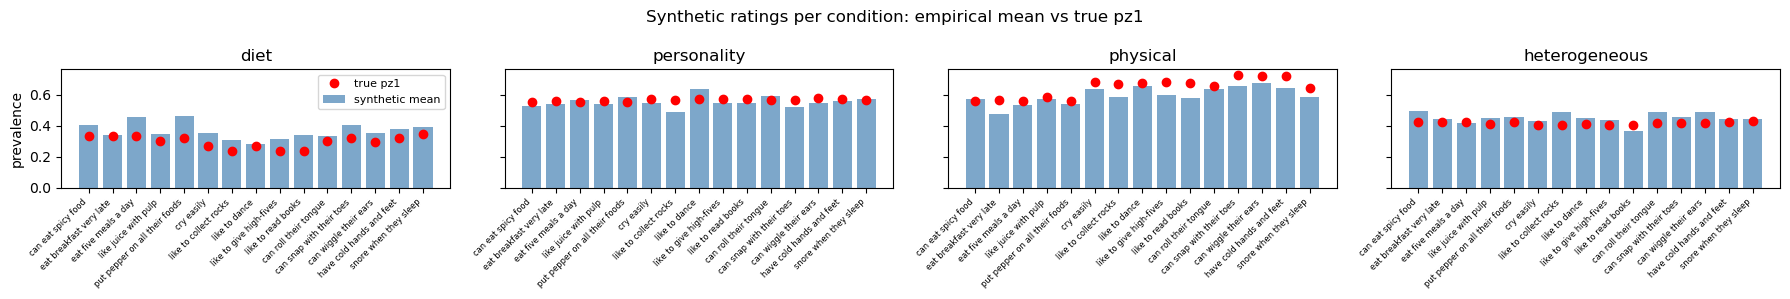

In [4]:
ALPHA_KL, BETA_KL   = 5.0, 1.0   # kind-linked component: high prevalence
ALPHA_NKL, BETA_NKL = 1.0, 5.0   # non-kind-linked: low prevalence
N_PARTICIPANTS_COND = {'diet': 100, 'personality': 100, 'physical': 100, 'heterogeneous': 100}

responses_cond = {}
for c in CONDITIONS:
    Nc = N_PARTICIPANTS_COND[c]
    ratings = np.zeros((Nc, J))
    for j in range(J):
        z     = rng.uniform(size=Nc) < pz1_test_true_cond[c][j]
        draws = np.where(z,
                         rng.beta(ALPHA_KL, BETA_KL, Nc),
                         rng.beta(ALPHA_NKL, BETA_NKL, Nc))
        ratings[:, j] = np.round(draws * 100) / 100   # discretize to slider grid
    responses_cond[c] = jnp.array(ratings)
    print(f"  {c:<14}: {Nc} participants -> responses {responses_cond[c].shape}")

# stacked in condition order -- used to fit the shared Beta shapes across all participants
responses_all = jnp.concatenate([responses_cond[c] for c in CONDITIONS], axis=0)
N_cond = {c: int(responses_cond[c].shape[0]) for c in CONDITIONS}
print(f"stacked responses_all: {responses_all.shape}")

fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
for ax, c in zip(axes, CONDITIONS):
    ax.bar(range(J), np.array(responses_cond[c].mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
    ax.plot(range(J), pz1_test_true_cond[c], 'ro', label='true pz1')
    ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=6)
    ax.set_title(c)
axes[0].set_ylabel('prevalence'); axes[0].legend(fontsize=8)
fig.suptitle('Synthetic ratings per condition: empirical mean vs true pz1')
plt.tight_layout(); plt.show()

## Inference: pyVBMC over (length_scale, mu_0)

Identical `log_joint` to `model-study9-vbmc-condition-stratified-linking.ipynb`: per evaluation,
sample each condition's coherences via NUTS, fit the SHARED Beta-mixture shapes ONCE across all
conditions' participants (weighted by each condition's own posterior-mean `pz1`), then score each
condition's thinned draws under those shared shapes (logsumexp) and sum across conditions.
`output_scale` and `beta` are fixed at their true values (as in the real run). Lighter MCMC than
the real run since this is a pipeline check.

In [5]:
FIXED_PARAMS = {
    'output_scale': TRUE_PARAMS['output_scale'],
    'beta':         TRUE_PARAMS['beta'],
}

N_WARMUP   = 300
N_SAMPLES  = 800        # per condition; 4 chains per eval
STEP       = 5          # thinning
MAX_EVALS  = 150         # VBMC budget knob (default noisy budget is 300; raise for a tighter posterior)

def condition_pz1_draws(x_train_c, u_train_c, params):
    '''Thinned coherence draws (S, J) = sigmoid(y_test) for one condition's trained region.'''
    ldf = make_log_density_fn_joint(u_train_c, x_train_c, x_test, params)
    ip  = {'training_coherences': jnp.zeros(x_train_c.shape[0]), 'test_coherences': jnp.zeros(J)}
    k = jax.random.PRNGKey(0); k, wk = jax.random.split(k)
    w = blackjax.window_adaptation(blackjax.nuts, ldf)
    (st, npar), _ = w.run(wk, ip, num_steps=N_WARMUP)
    nuts = blackjax.nuts(ldf, **npar); step = jax.jit(lambda s, key: nuts.step(key, s))
    tc = []
    for key in jax.random.split(k, N_SAMPLES)[:-1]:
        st, _ = step(st, key)
        tc.append(np.array(st.position['test_coherences']))
    return np.array(jax.nn.sigmoid(np.array(tc)[::STEP]))   # (S, J)

print(f"MCMC: {N_WARMUP} warmup, {N_SAMPLES} samples, thin {STEP} -> ~{(N_SAMPLES-1)//STEP} draws per condition")

MCMC: 300 warmup, 800 samples, thin 5 -> ~159 draws per condition


In [6]:
eval_count = [0]
eval_log   = []   # [(phi, log_joint_val, noise_std), ...]

def log_joint(phi):
    '''Condition-stratified log joint with a SHARED Beta-mixture linking function.

    Per eval: sample each condition's coherences; fit the per-feature shapes ONCE across all
    participants using condition-specific weights (shapes shared, condition-invariant); then score
    each condition's draws against those shared shapes and sum. phi = [log_ls, mu_0].
    '''
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    length_scale = float(np.exp(log_ls))
    eval_count[0] += 1
    print(f"  eval {eval_count[0]:3d}: ls={length_scale:.3f}  mu_0={mu_0:.3f}", end="  ")

    # same priors as the real run
    log_prior_ls  = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    log_prior_mu0 = float(-0.5 * mu_0 ** 2)
    log_prior = log_prior_ls + log_prior_mu0

    params = {**FIXED_PARAMS, 'length_scale': length_scale, 'mu_0': mu_0}

    # 1. per-condition coherence draws
    pz1_draws = {c: condition_pz1_draws(x_train_cond[c], u_train_cond[c], params) for c in CONDITIONS}
    pz1_bar   = {c: pz1_draws[c].mean(axis=0) for c in CONDITIONS}

    # 2. SHARED shapes: fit once across all participants, each weighted by THEIR condition's pz1
    pz1_weights = jnp.concatenate(
        [jnp.tile(jnp.array(pz1_bar[c]), (N_cond[c], 1)) for c in CONDITIONS], axis=0)  # (N_total, J)
    beta_params = fit_beta_mixtures_all_features(responses_all, pz1_weights)            # (J, 4) shared

    # 3. score each condition's draws under the shared shapes; logsumexp over draws; sum
    total_ll, var_terms = 0.0, []
    for c in CONDITIONS:
        S = pz1_draws[c].shape[0]
        ll_s = [float(beta_mixture_log_likelihood(responses_cond[c], jnp.array(pz1_draws[c][s]), beta_params))
                for s in range(S)]
        total_ll += float(scipy_logsumexp(ll_s) - np.log(S))
        var_terms.append(np.var(ll_s))

    noise_std = float(np.sqrt(sum(var_terms)))   # combined MC noise across conditions
    if not np.isfinite(total_ll):
        total_ll, noise_std = -1e6, 1.0

    log_joint_val = float(total_ll + log_prior)
    print(f"log_lik={total_ll:.1f}  noise_std={noise_std:.2f}  log_joint={log_joint_val:.1f}")
    eval_log.append((np.array(phi, dtype=float), log_joint_val, noise_std))
    return log_joint_val, max(noise_std, 1.0)

In [7]:
# --- pyVBMC varG-squeeze patch (same bug fix as the real-data notebook) ---
import pyvbmc.vbmc.variational_optimization as _vopt
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig_gp_log_joint = _vopt._gp_log_joint
    def _gp_log_joint_scalar_varg(*args, **kwargs):
        out = list(_orig_gp_log_joint(*args, **kwargs))
        if out[2] is not None:
            out[2] = float(np.squeeze(out[2]))
        return tuple(out)
    _gp_log_joint_scalar_varg._varg_squeeze_patch = True
    _vopt._gp_log_joint = _gp_log_joint_scalar_varg
    print("patched _gp_log_joint (varG squeeze)")

# Start AWAY from the truth so recovery is a real test (true ls=2.1, mu_0=0.5)
x0  = np.array([np.log(0.3), 0.0])
lb  = np.array([np.log(0.03), -4.0])
ub  = np.array([np.log(2.5),   4.0])     # ~3x cloud diameter (0.78); above this = trait-blind
plb = np.array([np.log(0.08), -2.0])
pub = np.array([np.log(1.0),   2.0])
print(f"Start: ls={np.exp(x0[0]):.2f}, mu_0={x0[1]:.2f}  (true: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']})")

vbmc = VBMC(log_joint, x0, lb, ub, plb, pub,
            options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS})
vbmc_result, vbmc_stats = vbmc.optimize()

patched _gp_log_joint (varG squeeze)
Start: ls=0.30, mu_0=0.00  (true: ls=2.1, mu_0=0.5)
Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=0.300  mu_0=0.000  log_lik=-26564.2  noise_std=266.79  log_joint=-26564.2
  eval   2: ls=0.132  mu_0=-1.742  log_lik=-26592.2  noise_std=292.23  log_joint=-26594.2
  eval   3: ls=0.170  mu_0=-1.199  log_lik=-26535.5  noise_std=291.99  log_joint=-26536.5
  eval   4: ls=0.511  mu_0=1.281  log_lik=-26636.8  noise_std=174.07  log_joint=-26637.6
  eval   5: ls=0.590  mu_0=-0.316  log_lik=-26528.8  noise_std=259.17  log_joint=-26528.9
  eval   6: ls=0.089  mu_0=-1.241  log_lik=-26597.1  noise_std=265.05  log_joint=-26598.5
  eval   7: ls=0.66

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar subtract
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar multiply
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),


  eval  67: ls=2.499  mu_0=-3.958  log_lik=-26408.5  noise_std=167.61  log_joint=-26416.9
  eval  68: ls=2.500  mu_0=-3.893  log_lik=-26417.8  noise_std=181.33  log_joint=-26426.0
  eval  69: ls=2.499  mu_0=-3.937  log_lik=-26431.2  noise_std=170.10  log_joint=-26439.5
  eval  70: ls=2.391  mu_0=-3.749  log_lik=-26422.1  noise_std=146.71  log_joint=-26429.7
    12         70      -26455.98        26.61         3.12        2       88.3     
  eval  71: ls=1.096  mu_0=-3.950  log_lik=-26382.2  noise_std=232.86  log_joint=-26390.1
  eval  72: ls=2.500  mu_0=-3.955  log_lik=-26418.4  noise_std=138.67  log_joint=-26426.8
  eval  73: ls=2.495  mu_0=-3.915  log_lik=-26390.3  noise_std=156.49  log_joint=-26398.6
  eval  74: ls=2.500  mu_0=-3.893  log_lik=-26457.9  noise_std=155.51  log_joint=-26466.0
  eval  75: ls=2.380  mu_0=1.349  log_lik=-26627.3  noise_std=82.94  log_joint=-26628.7
    13         75      -26419.19        17.57         0.84        2       37.9     
  eval  76: ls=2.500  mu

## Recovery results

Posterior over `(length_scale, mu_0)` vs the true values (red). Good recovery = the true point
sits inside the bulk of the posterior. Note `mu_0` may land slightly off the true value because
each condition's realized GP draw mean differs from `mu_0` — that's expected sampling scatter,
not a pipeline error.

param             true   post mean  post median                95% CI
length_scale     2.100       0.749        0.066   [0.030, 2.500]
mu_0             0.500       1.292        1.847   [-3.533, 3.975]

convergence: no  (evals: 150, ELBO: -26448.8)


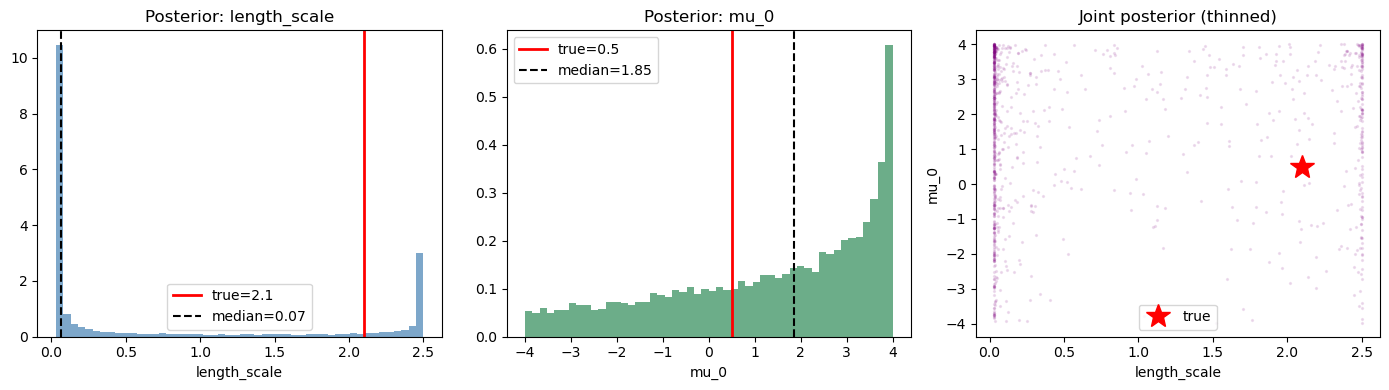

In [8]:
phi_samples, _ = vbmc_result.sample(int(1e4))
ls_samples  = np.exp(phi_samples[:, 0])
mu0_samples = phi_samples[:, 1]

ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']
print(f"{'param':<14}{'true':>8}{'post mean':>12}{'post median':>13}{'95% CI':>22}")
print(f"{'length_scale':<14}{ls_true:>8.3f}{ls_samples.mean():>12.3f}{np.median(ls_samples):>13.3f}"
      f"   [{np.percentile(ls_samples,2.5):.3f}, {np.percentile(ls_samples,97.5):.3f}]")
print(f"{'mu_0':<14}{mu0_true:>8.3f}{mu0_samples.mean():>12.3f}{np.median(mu0_samples):>13.3f}"
      f"   [{np.percentile(mu0_samples,2.5):.3f}, {np.percentile(mu0_samples,97.5):.3f}]")
print(f"\nconvergence: {vbmc_stats['convergence_status']}  (evals: {vbmc_stats['func_count']}, "
      f"ELBO: {vbmc_stats['elbo']:.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Posterior: length_scale'); axes[0].legend()

axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Posterior: mu_0'); axes[1].legend()

axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].plot(ls_true, mu0_true, 'r*', ms=18, label='true')
axes[2].set_xlabel('length_scale'); axes[2].set_ylabel('mu_0')
axes[2].set_title('Joint posterior (thinned)'); axes[2].legend()
plt.tight_layout(); plt.show()

Condition: diet
  [diet          ] (a) model-free (ratings > 0.5)     r=+0.706  MAE=0.042
  [diet          ] (b) predicted @ recovered (ls=0.07, mu0=1.85) r=+0.412  MAE=0.511
  [diet          ] (c) predicted @ true (ls=2.1, mu0=0.5) r=-0.881  MAE=0.427
Condition: personality
  [personality   ] (a) model-free (ratings > 0.5)     r=+0.153  MAE=0.031
  [personality   ] (b) predicted @ recovered (ls=0.07, mu0=1.85) r=+0.746  MAE=0.236
  [personality   ] (c) predicted @ true (ls=2.1, mu0=0.5) r=+0.450  MAE=0.120
Condition: physical
  [physical      ] (a) model-free (ratings > 0.5)     r=+0.846  MAE=0.034
  [physical      ] (b) predicted @ recovered (ls=0.07, mu0=1.85) r=+0.782  MAE=0.169
  [physical      ] (c) predicted @ true (ls=2.1, mu0=0.5) r=-0.085  MAE=0.064
Condition: heterogeneous
  [heterogeneous ] (a) model-free (ratings > 0.5)     r=+0.143  MAE=0.036
  [heterogeneous ] (b) predicted @ recovered (ls=0.07, mu0=1.85) r=-0.375  MAE=0.402
  [heterogeneous ] (c) predicted @ true (ls=2.

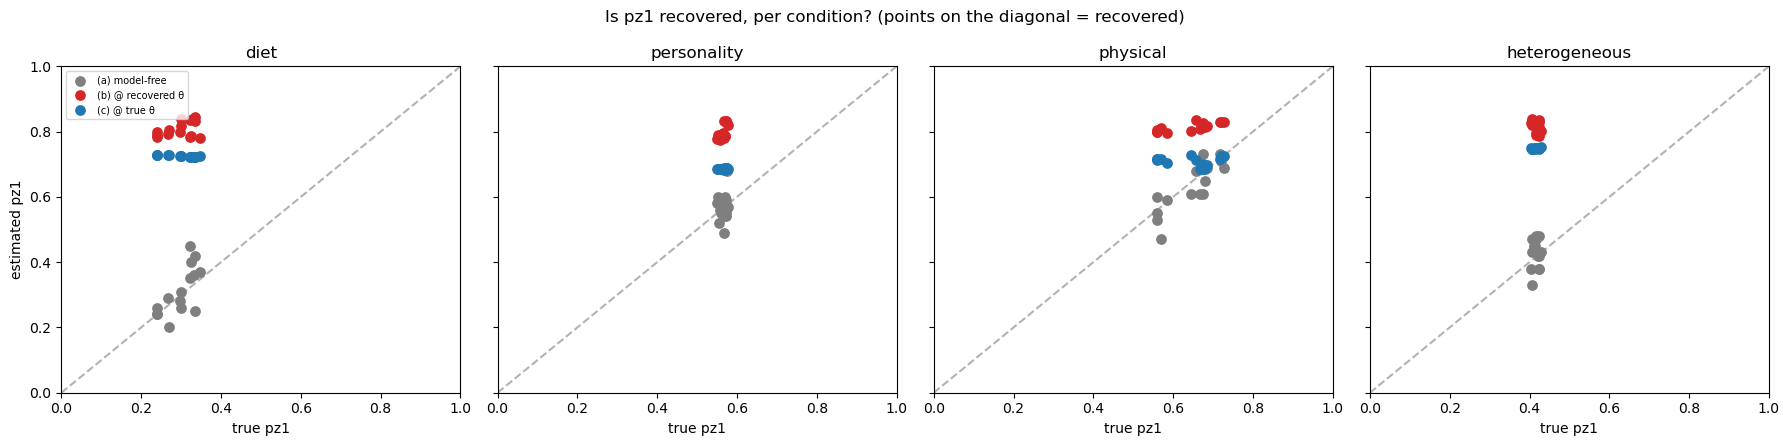

In [9]:
# === Diagnostic: is pz1 recovered per condition, or does the linking function absorb it? ===
# KEY: the MCMC samples each condition's test coherences from that condition's TRAINING
# utterances + GP prior only -- the test ratings never enter the sampler. So "predicted pz1" is
# the model's prediction of test coherence from training, at a given theta, for that condition.
# We compare each condition's true pz1 against:
#   (a) a model-free estimate from that condition's ratings (high-mode fraction)  -> do the
#       ratings encode pz1?
#   (b) predicted pz1 at the RECOVERED theta                                       -> what the
#       fit believes
#   (c) predicted pz1 at the TRUE theta                                            -> best case
#       for the model
#
# Reading it (per condition):
#   - If (a) tracks true pz1 but (b)/(c) do NOT, that condition's training+GP can't predict test
#     coherence (test features weakly coupled to training / weak utterance signal) -> theta
#     unidentifiable from that condition because the ratings' pz1 info is never used to constrain
#     the coherences.
#   - If (b)/(c) track true pz1 but length_scale is still flat -> pz1 is fine; ls is just hard to
#     estimate (a smoothness parameter from one sparse field realization per condition).
#   - If predicted pz1 is far from the ratings' pz1, the SHARED per-feature Beta shapes are
#     absorbing the mismatch (the "linking flexibility" mechanism) -- now harder to do across
#     conditions since the shapes must fit all four simultaneously.

def predicted_pz1(c, ls, mu0):
    '''Posterior-mean pz1 = E[sigmoid(y_test)] from the GP+utterance model at (ls, mu0), for
    condition c.'''
    params = {**FIXED_PARAMS, 'length_scale': float(ls), 'mu_0': float(mu0)}
    return condition_pz1_draws(x_train_cond[c], u_train_cond[c], params).mean(0)   # (J,)

ls_rec, mu0_rec = float(np.median(ls_samples)), float(np.median(mu0_samples))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, CONDITIONS):
    pz1_freefit  = np.array((responses_cond[c] > 0.5).mean(0))             # (a) model-free
    pz1_pred_rec = predicted_pz1(c, ls_rec, mu0_rec)                       # (b) recovered theta
    pz1_pred_tru = predicted_pz1(c, TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0'])  # (c) true theta

    def _summ(name, est, true):
        r   = np.corrcoef(true, est)[0, 1]
        mae = np.mean(np.abs(true - est))
        print(f"  [{c:<14}] {name:<34} r={r:+.3f}  MAE={mae:.3f}")

    print(f"Condition: {c}")
    _summ("(a) model-free (ratings > 0.5)", pz1_freefit, pz1_test_true_cond[c])
    _summ(f"(b) predicted @ recovered (ls={ls_rec:.2f}, mu0={mu0_rec:.2f})", pz1_pred_rec, pz1_test_true_cond[c])
    _summ(f"(c) predicted @ true (ls={TRUE_PARAMS['length_scale']}, mu0={TRUE_PARAMS['mu_0']})", pz1_pred_tru, pz1_test_true_cond[c])

    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.6, zorder=0)
    ax.scatter(pz1_test_true_cond[c], pz1_freefit,  s=45, color='tab:gray',   label='(a) model-free')
    ax.scatter(pz1_test_true_cond[c], pz1_pred_rec, s=45, color='tab:red',    label='(b) @ recovered θ')
    ax.scatter(pz1_test_true_cond[c], pz1_pred_tru, s=45, color='tab:blue',   label='(c) @ true θ')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('true pz1'); ax.set_title(c)
axes[0].set_ylabel('estimated pz1'); axes[0].legend(loc='upper left', fontsize=7)
fig.suptitle('Is pz1 recovered, per condition? (points on the diagonal = recovered)')
plt.tight_layout(); plt.show()

## 1D recovery — isolate each parameter

To separate "each parameter is individually unidentifiable" from "the two are confounded in the
joint fit", recover each one alone with the other **fixed at its true value**:

- **lengthscale only** (mu_0 fixed at true)
- **mu_0 only** (lengthscale fixed at true)

Interpretation: if a parameter recovers well alone but not in the joint 2D fit, the problem is the
joint ridge/confound between them. If it fails even alone, it's individually unidentifiable from
this data. (Uses a lighter VBMC budget, `MAX_EVALS_1D`, since 1D problems converge faster.) Uses
the same condition-stratified, shared-shapes likelihood as the 2D fit above.

In [10]:
# Shared likelihood body (condition-stratified MCMC + once-per-eval shared beta fit),
# reused by both 1D objectives.
import pyvbmc.vbmc.variational_optimization as _vopt   # ensure varG-squeeze patch is active
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig = _vopt._gp_log_joint
    def _patched(*a, **k):
        out = list(_orig(*a, **k))
        out[2] = None if out[2] is None else float(np.squeeze(out[2]))
        return tuple(out)
    _patched._varg_squeeze_patch = True
    _vopt._gp_log_joint = _patched

def _loglik_noise(length_scale, mu_0):
    params = {**FIXED_PARAMS, 'length_scale': float(length_scale), 'mu_0': float(mu_0)}

    pz1_draws = {c: condition_pz1_draws(x_train_cond[c], u_train_cond[c], params) for c in CONDITIONS}
    pz1_bar   = {c: pz1_draws[c].mean(axis=0) for c in CONDITIONS}

    pz1_weights = jnp.concatenate(
        [jnp.tile(jnp.array(pz1_bar[c]), (N_cond[c], 1)) for c in CONDITIONS], axis=0)
    beta_params = fit_beta_mixtures_all_features(responses_all, pz1_weights)

    total_ll, var_terms = 0.0, []
    for c in CONDITIONS:
        S = pz1_draws[c].shape[0]
        ll_s = [float(beta_mixture_log_likelihood(responses_cond[c], jnp.array(pz1_draws[c][s]), beta_params))
                for s in range(S)]
        total_ll += float(scipy_logsumexp(ll_s) - np.log(S))
        var_terms.append(np.var(ll_s))

    noise_std = float(np.sqrt(sum(var_terms)))
    if not np.isfinite(total_ll):
        total_ll, noise_std = -1e6, 1.0
    return total_ll, max(noise_std, 1.0)

_n_ls = [0]
def log_joint_ls_only(phi):
    '''1D: recover lengthscale only; mu_0 held at the TRUE value.'''
    log_ls = float(phi[0]); ls = float(np.exp(log_ls))
    _n_ls[0] += 1
    ll, ns = _loglik_noise(ls, TRUE_PARAMS['mu_0'])
    lp = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    print(f"  [ls-only] {_n_ls[0]:3d}: ls={ls:.3f}  log_lik={ll:.1f}  noise={ns:.1f}")
    return float(ll + lp), ns

_n_mu = [0]
def log_joint_mu_only(phi):
    '''1D: recover mu_0 only; lengthscale held at the TRUE value.'''
    mu_0 = float(phi[0])
    _n_mu[0] += 1
    ll, ns = _loglik_noise(TRUE_PARAMS['length_scale'], mu_0)
    lp = float(-0.5 * mu_0 ** 2)
    print(f"  [mu-only] {_n_mu[0]:3d}: mu_0={mu_0:.3f}  log_lik={ll:.1f}  noise={ns:.1f}")
    return float(ll + lp), ns

MAX_EVALS_1D = 80   # lighter than the 2D run; 1D problems converge faster
print("defined 1D objectives: log_joint_ls_only, log_joint_mu_only")

defined 1D objectives: log_joint_ls_only, log_joint_mu_only


Reshaping x0 to row vector.
Reshaping lower bounds to (1, 1).
Reshaping upper bounds to (1, 1).
Reshaping plausible lower bounds to (1, 1).
Reshaping plausible upper bounds to (1, 1).
vbmc:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds PLB and PUB. Expanding the plausible bounds...
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  [ls-only]   1: ls=1.500  log_lik=-26584.4  noise=119.2
  [ls-only]   2: ls=0.593  log_lik=-26596.5  noise=179.2
  [ls-only]   3: ls=1.141  log_lik=-26595.0  noise=138.0
  [ls-only]   4: ls=1.277  log_lik=-26604.9  noise=148.3
  [ls-only]   5: ls=0.483  log_lik=-26584.9  noise=202.4
  [ls-only]   6: ls=1.449  log_lik=-26619.4  noise=108.1
  [ls-only]   7: ls=1.176  log_lik=-26564.7  noise=115.9
  [ls-only]   8: ls=0.414  log_lik=-26588.6  noise=235.8
  [ls-only]   9: ls=0.319  log_lik=-26599.0  n

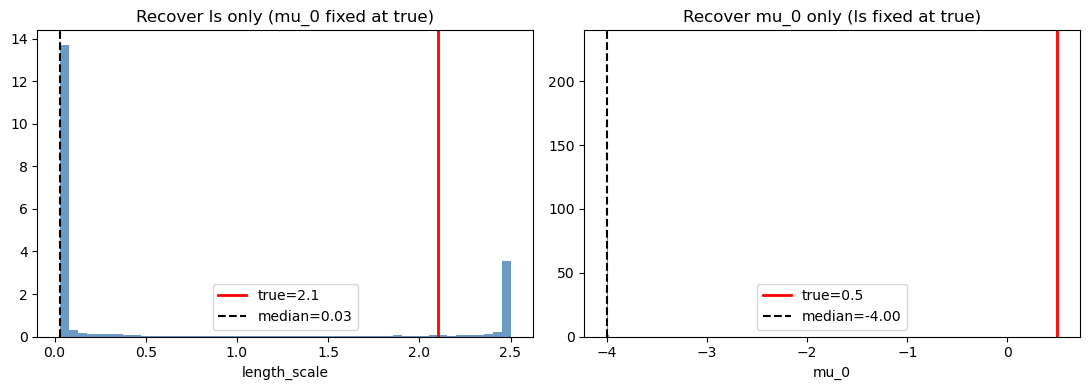

In [11]:
ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']

# --- lengthscale only (mu_0 fixed at true) ---
vbmc_ls = VBMC(log_joint_ls_only,
               np.array([np.log(1.5)]), np.array([np.log(0.03)]), np.array([np.log(2.5)]),
               np.array([np.log(0.08)]), np.array([np.log(1.0)]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_ls, stats_ls = vbmc_ls.optimize()
ls_post = np.exp(res_ls.sample(int(1e4))[0][:, 0])

# --- mu_0 only (lengthscale fixed at true) ---
vbmc_mu = VBMC(log_joint_mu_only,
               np.array([1.0]), np.array([-4.0]), np.array([4.0]),
               np.array([-2.0]), np.array([2.0]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_mu, stats_mu = vbmc_mu.optimize()
mu0_post = res_mu.sample(int(1e4))[0][:, 0]

print(f"\nlengthscale-only:  true={ls_true}   median={np.median(ls_post):.3f}   "
      f"95% CI [{np.percentile(ls_post,2.5):.3f}, {np.percentile(ls_post,97.5):.3f}]   "
      f"({stats_ls['convergence_status']})")
print(f"mu_0-only:         true={mu0_true}   median={np.median(mu0_post):.3f}   "
      f"95% CI [{np.percentile(mu0_post,2.5):.3f}, {np.percentile(mu0_post,97.5):.3f}]   "
      f"({stats_mu['convergence_status']})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ls_post, bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_post), color='k', ls='--', label=f'median={np.median(ls_post):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Recover ls only (mu_0 fixed at true)'); axes[0].legend()
axes[1].hist(mu0_post, bins=50, density=True, color='seagreen', alpha=0.8)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_post), color='k', ls='--', label=f'median={np.median(mu0_post):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Recover mu_0 only (ls fixed at true)'); axes[1].legend()
plt.tight_layout(); plt.show()